# Segmenting Biological Tissue Images


<div style="background-color: #f0f8ff; border: 2px solid #4682b4; padding: 10px;">
<a href="https://colab.research.google.com/github/DeepTrackAI/DeepLearningCrashCourse/blob/main/Ch05_UNet/ec05_1_unet/unet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
<strong>If using Colab/Kaggle:</strong> You need to uncomment the code in the cell below this one.
</div>

In [126]:
# !pip install deeplay deeptrack  # Uncomment if using Colab/Kaggle.

This notebook provides you with a complete code example that segments the images of a biological tissue using a U-Net employing early stopping to prevent overfitting.

<div style="background-color: #f0f8ff; border: 2px solid #4682b4; padding: 10px;">
<strong>Note:</strong> This notebook contains the Code Example 5-1 from the book  

**Deep Learning Crash Course**  
Giovanni Volpe, Benjamin Midtvedt, Jesús Pineda, Henrik Klein Moberg, Harshith Bachimanchi, Joana B. Pereira, Carlo Manzo  
No Starch Press, San Francisco (CA), 2026  
ISBN-13: 9781718503922  

[https://nostarch.com/deep-learning-crash-course](https://nostarch.com/deep-learning-crash-course)

You can find the other notebooks on the [Deep Learning Crash Course GitHub page](https://github.com/DeepTrackAI/DeepLearningCrashCourse).
</div>

## Loading the Dataset with Segmented Tissue Images

The dataset consists of 20 serial section Transmission Electron Microscopy (ssTEM) images of the ventral nerve cord of the Drosophila melanogaster, a fruit fly, whose size is 1024 x 1024 pixels. In addition to the ssTEM images, the dataset also contains ground-truth segmentations of the neuronal structures. 
For simplicity, you'll only consider the segmentation of the neuronal intracellular regions and mitochondria.

Download the dataset ...

In [127]:
import skimage
import pandas as pd
import os
import deeptrack as dt
import torch
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torchvision.transforms import Compose, Resize, ToTensor, InterpolationMode
from torchvision.transforms.v2 import Transform
from torch.utils.data import Dataset
from PIL import Image


data_dir = os.path.join(".", "data")
ann_path = os.path.join(data_dir, "annotations", "list.txt")
im_path = os.path.join(data_dir, "images")

annotations = pd.read_csv(ann_path, sep=" ", header=None, names=["Image", "ID", "SPECIES", "BREED ID"], skiprows=6)

print(f"Number of images: {len(annotations)}")
# print(annotations.iloc[0])
# print(annotations["Image"][0:5])

files = [os.path.join(im_path, f"{annotations['Image'][i]}.jpg") for i in range(len(annotations))]

class NormalizeMinMax(Transform):
    def __init__(self):
        super().__init__()

    def transform(self, image, *args):
        image = (image - torch.min(image)) / (torch.max(image) - torch.min(image))
        return torch.tensor(image, dtype=torch.float)

class EnforceRGB(Transform):
    def __init__(self):
        super().__init__()

    def transform(self, image, *args):
        if image.shape[0] != 3:
            image = image[:3, :, :]
        return torch.tensor(image, dtype=torch.float)

class Grayscale(Transform):
    def __init__(self):
        super().__init__()

    def transform(self, image, *args):
        # print(image.shape)
        image = image.permute(1, 2, 0)
        if image.shape[2] != 3:
            image = image[:, :, :3]

        image = skimage.color.rgb2gray(image)
        image = image.reshape(1, image.shape[0], image.shape[1])
        return torch.tensor(image, dtype=torch.float)
    
    
class SquarePad(Transform):
    def __init__(self):
        super().__init__()

    def transform(self, image, *args):    
        h, w = image.shape[1], image.shape[2]
        if h == w:
            return image
        elif h > w:
            pad = (h - w) // 2
            padded_image = np.pad(image, ((0, 0), (0, 0), (pad, pad)), mode="linear_ramp", end_values=0)
        else:
            pad = (w - h) // 2
            padded_image = np.pad(image, ((0, 0), (pad, pad), (0, 0)), mode="linear_ramp", end_values=0)
        return torch.tensor(padded_image, dtype=torch.float)
    
class SquareCrop(Transform):
    def __init__(self):
        super().__init__()

    def transform(self, image, *args):
        h, w =image.size
        print()
        print(h, w)

        if h > w:
            if (h-w)%2==0:
                image = image.crop((0, (h-w)//2, w, h-((h-w)//2)))
            else:
                image = image.crop((0, (h-w)//2-1, w, h-((h-w)//2)))
        else:
            if (h-w)%2==0:
                image = image.crop(((w-h)//2, 0, w-((w-h)//2), h))
            else:
                image = image.crop(((w-h)//2-1, 0, w-((w-h)//2), h))
        print(image.size)
        return image


class AnimalTrimapDataset(Dataset):
    def __init__(self, data_dir, img_dir, img_labels,
                 transform=Compose([
                        # SquareCrop(),
                        ToTensor(),
                        EnforceRGB(),
                        # Grayscale(),
                        Resize((128, 128)),
                        NormalizeMinMax(),
                ]), 
                trimap_transform=Compose([
                        # SquareCrop(),
                        # ToTensor(),
                        Resize((128, 128), interpolation=InterpolationMode.NEAREST_EXACT),
                        np.array
                        # NormalizeMinMax(),
                ]), 
                loader=Image.open):
        self.img_labels = img_labels
        self.data_dir = data_dir
        self.img_dir = img_dir
        self.transform = transform
        self.trimap_transform = trimap_transform
        self.loader = loader
        self.img_size = (128, 128)

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, str(self.img_labels.iloc[idx]) + ".jpg")
        trimap_path = os.path.join(self.data_dir, "annotations", "trimaps", "" + str(self.img_labels.iloc[idx]) + ".png")
        # trimap_path = os.path.join(self.data_dir, "annotations", "trimaps", "._" + str(self.img_labels.iloc[idx]) + ".png")
        image = self.loader(img_path)
        image = self.transform(image)

        # print(trimap_path)
        # m = np.array(Image.open(trimap_path))
        trimap = self.loader(trimap_path)
        trimap = self.trimap_transform(trimap)
        # print(trimap.shape)
        new_trimap = np.zeros((3, trimap.shape[0], trimap.shape[1]))
        new_trimap[0][np.where(trimap==1)] = 1
        new_trimap[1][np.where((trimap!=1) & (trimap!=2))] = 1
        new_trimap[2][np.where(trimap==2)] = 1
        new_trimap = torch.tensor(new_trimap)
        
        # print(image.shape)
        # print(new_trimap.shape)
        
        # print(np.ones_like(np.where(trimap==1)))
        # print(image.shape, self.img_labels[idx])
        return image, new_trimap




# %% Load data
dataset = AnimalTrimapDataset(
    data_dir=data_dir, 
    img_dir=im_path,
    img_labels=annotations['Image'],
)

Number of images: 7349


C:\Users\jojac\AppData\Local\Temp\ipykernel_17136\3077789329.py:44: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(image, dtype=torch.float)
C:\Users\jojac\AppData\Local\Temp\ipykernel_17136\3077789329.py:35: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(image, dtype=torch.float)


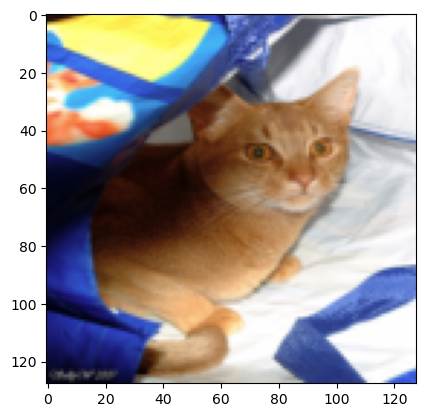

C:\Users\jojac\AppData\Local\Temp\ipykernel_17136\2743052907.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  plt.imshow(torch.tensor(trimap).permute(1,2,0))


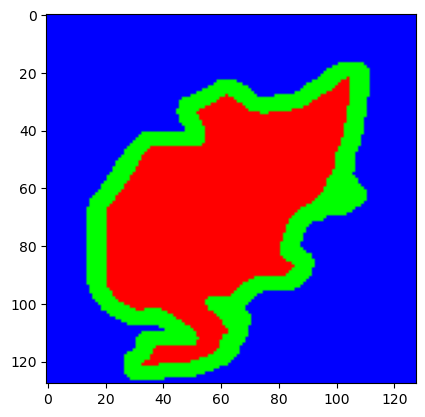

In [128]:
for i in range(1):
    img, trimap = dataset[i]
    # plt.imshow(img.squeeze(), cmap="gray")
    plt.imshow(img.permute(1,2,0))
    plt.show()

    plt.imshow(torch.tensor(trimap).permute(1,2,0))
    plt.show()

In [129]:
train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(dataset, [0.7, 0.1, 0.2])

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

In [130]:
# import os

# if not os.path.exists("tissue_images_dataset"):
#     os.system("git clone https://github.com/DeepTrackAI/tissue_images_dataset")

# raw_path = os.path.join("tissue_images_dataset", "stack1", "raw")
# seg_path = os.path.join("tissue_images_dataset", "stack1", "labels")

... create the sources to manage the images during training ...

In [131]:
# import deeptrack as dt

# raw_paths = dt.sources.ImageFolder(root=raw_path)
# seg_paths = dt.sources.ImageFolder(root=seg_path)
# paths = dt.sources.Source(raw=raw_paths, label=seg_paths)
# train_paths, val_paths, test_paths = \
#     dt.sources.random_split(paths, [0.8, 0.1, 0.1])

# train_srcs = train_paths.product(flip_ud=[True, False], flip_lr=[True, False])
# val_srcs = val_paths.constants(flip_ud=False, flip_lr=False)
# test_srcs = test_paths.constants(flip_ud=False, flip_lr=False)

# sources = dt.sources.Join(train_srcs, val_srcs, test_srcs)

... check how many images are loaded.

In [132]:
# print(f"Raw images: {len(raw_paths)}")
# print(f"Segmentation labels: {len(seg_paths)}")

## Creating the Data Pipelines

Implement a function to filter the labels in the segmentation map ...

In [133]:
# import numpy as np

# def select_labels(class_labels):
#     """Create a function to filter and remap labels in a segmentation map."""
#     def inner(segmentation):
#         seg = segmentation.copy()
#         mask = seg * np.isin(seg, class_labels).astype(np.uint8)
#         new_seg = (np.select([mask == c for c in class_labels],
#                              np.arange(len(class_labels)) + 1)
#                    .astype(np.uint8).squeeze())
#         one_hot_encoded_seg = np.eye(len(class_labels) + 1)[new_seg]
#         return one_hot_encoded_seg        
#     return inner

... define the pipelines ...

In [134]:
# import torch

# im_pip = dt.LoadImage(sources.raw.path) >> dt.NormalizeMinMax()
# seg_pip = (dt.LoadImage(sources.label.path)
#            >> dt.Lambda(select_labels, class_labels=[255, 191]))
# pip = ((im_pip & seg_pip) >> dt.FlipLR(sources.flip_lr)
#        >> dt.FlipUD(sources.flip_ud) >> dt.MoveAxis(2, 0)
#        >> dt.pytorch.ToTensor(dtype=torch.float))

... define the training and validation datasets ...

In [135]:
# train_dataset = dt.pytorch.Dataset(pip, train_srcs)
# val_dataset = dt.pytorch.Dataset(pip, val_srcs)

... and plot the input image and corresponding ground-truth segmentation.

C:\Users\jojac\AppData\Local\Temp\ipykernel_17136\3077789329.py:44: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(image, dtype=torch.float)
C:\Users\jojac\AppData\Local\Temp\ipykernel_17136\3077789329.py:35: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(image, dtype=torch.float)


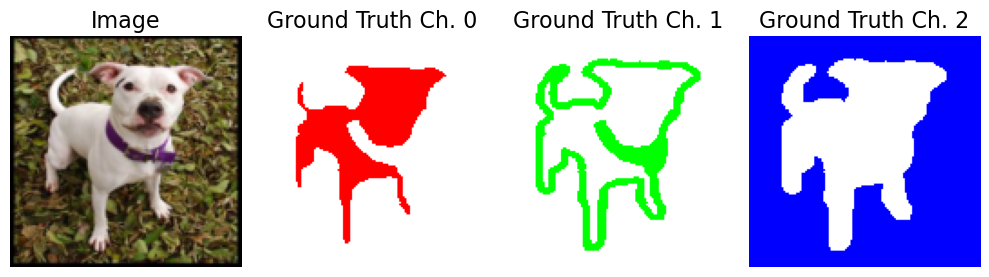

In [136]:
import matplotlib.pyplot as plt

image, segmentation = train_dataset[0]

fig, axs = plt.subplots(1, 4, figsize=(10, 5))

axs[0].imshow(image.permute(1, 2, 0), cmap="gray")
axs[0].set_title("Image", fontsize=16)
axs[0].set_axis_off()

for i in range(segmentation.shape[0]):
    segmentation_color = torch.ones_like(segmentation)
    for j in range(segmentation.shape[0]):
        if j != i: segmentation_color[j, ...] = 1 - segmentation[i, ...]
    axs[i + 1].imshow(segmentation_color.permute(1, 2, 0))
    axs[i + 1].set_title(f"Ground Truth Ch. {i}", fontsize=16)
    axs[i + 1].set_axis_off()

plt.tight_layout()
plt.show()

## Defining and Training the U-Net

Define a class to compute Jaccard Index for multi-class predictions after taking the
channel with the maximum value ...

In [137]:
from torchmetrics.classification import MulticlassJaccardIndex

class ArgmaxJI(MulticlassJaccardIndex):
    """Compute Jaccard Index for multi-class predictions after argmax."""

    def update(self, preds, targets):
        """Update Jaccard Index using argmax of class predictions."""
        super().update(preds.argmax(dim=1), targets.argmax(dim=1))

... define and compile the U-Net ...

In [138]:
import deeplay as dl

ji_metric = ArgmaxJI(num_classes=3)

unet = dl.UNet2d(
    in_channels=3, channels=[128, 128, 256, 256], out_channels=3, skip=dl.Cat(),
)
unet.encoder.postprocess = None
unet.decoder.postprocess = None
unet_reg_template = dl.Regressor(
    model=unet, loss=torch.nn.CrossEntropyLoss(weight=torch.tensor([1, 1, 1])), metrics=[ji_metric],
    optimizer=dl.Adam(),
)
unet_reg = unet_reg_template.create()

print(unet_reg)

Regressor(
  (loss): CrossEntropyLoss()
  (optimizer): Adam[Adam]()
  (train_metrics): MetricCollection(
    (ArgmaxJI): ArgmaxJI(),
    prefix=train
  )
  (val_metrics): MetricCollection(
    (ArgmaxJI): ArgmaxJI(),
    prefix=val
  )
  (test_metrics): MetricCollection(
    (ArgmaxJI): ArgmaxJI(),
    prefix=test
  )
  (model): UNet2d(
    (encoder): ConvolutionalEncoder2d(
      (blocks): LayerList(
        (0): Conv2dBlock(
          (layer): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (activation): ReLU()
        )
        (1): Conv2dBlock(
          (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
          (layer): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (activation): ReLU()
        )
        (2): Conv2dBlock(
          (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
          (layer): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), paddin

... define the training and validation data loaders ...

In [139]:
# train_loader = dl.DataLoader(train_dataset, batch_size=2, shuffle=True)
# val_loader = dl.DataLoader(val_dataset, batch_size=2)

... and training the U-Net.

In [140]:
from lightning.pytorch.loggers import CSVLogger

# logger = CSVLogger("logs", name="train_100_epochs")
# trainer = dl.Trainer(max_epochs=100, accelerator="auto", logger=logger)
# trainer.fit(unet_reg, train_loader, val_loader)

## Observing Overfitting

Read the training metrics ...

In [141]:
# import pandas as pd

# metrics = pd.read_csv(os.path.join(logger.log_dir, "metrics.csv")).ffill()

... implement a function to plot the training metrics ...

In [142]:
def plot_training_metrics(m):
    """Plot training metrics by epoch."""
    fig, axs = plt.subplots(2, figsize=(6, 4))

    axs[0].plot(m["epoch"], m["train_loss_epoch"], label="Train Loss")
    axs[0].plot(m["epoch"], m["val_loss_epoch"], label="Validation Loss")
    axs[0].set_xlabel("Epoch")
    axs[0].set_ylabel("Loss")
    axs[0].legend()

    axs[1].plot(m["epoch"], m["trainArgmaxJI_epoch"], label="Train JI")
    axs[1].plot(m["epoch"], m["valArgmaxJI_epoch"], label="Validation JI")
    axs[1].set_xlabel("Epoch")
    axs[1].set_ylabel("Jaccard Index (JI)")
    axs[1].legend()

    plt.tight_layout()
    plt.show()

... and plot the training and validation metrics.

In [143]:
# plot_training_metrics(metrics)

## Preventing Overfitting

Train U-Net with early stopping to prevent overfitting ...

In [144]:
from lightning.pytorch.callbacks import EarlyStopping

early_stop_unet_reg = unet_reg_template.create()

early_stop = EarlyStopping(monitor="valArgmaxJI_epoch", mode="max", patience=5)
early_stop_logger = CSVLogger("logs", name="train_until_stagnation")

early_stop_trainer = dl.Trainer(max_epochs=100, logger=early_stop_logger,
                                callbacks=[early_stop])
early_stop_trainer.fit(early_stop_unet_reg, train_loader, val_loader)

┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ CrossEntropyLoss │      0 │ train │     0 │
│ 1 │ train_metrics │ MetricCollection │      0 │ train │     0 │
│ 2 │ val_metrics   │ MetricCollection │      0 │ train │     0 │
│ 3 │ test_metrics  │ MetricCollection │      0 │ train │     0 │
│ 4 │ model         │ UNet2d           │  4.4 M │ train │     0 │
│ 5 │ optimizer     │ Adam             │      0 │ train │     0 │
└───┴───────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 4.4 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 4.4 M                                                                                                
Total estimated model params size (MB): 17                                                                         
Modules in train mode: 53                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\jojac\anaconda3\envs\stoch\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\jojac\anaconda3\envs\stoch\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
C:\Users\jojac\AppData\Local\Temp\ipykernel_17136\3077789329.py:44: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(image, dtype=torch.float)
C:\Users\jojac\AppData\Local\Temp\ipykernel_17136\3077789329.py:35: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach()

c:\Users\jojac\anaconda3\envs\stoch\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Epoch 28: 100%|██████████| 81/81 [04:54<00:00,  0.28it/s, v_num=6, train_loss_step=0.316, trainArgmaxJI_step=0.692, val_loss_step=0.343, valArgmaxJI_step=0.658, val_loss_epoch=0.386, valArgmaxJI_epoch=0.661, train_loss_epoch=0.271, trainArgmaxJI_epoch=0.716]


... plot the training and validation metrics with early stopping ...

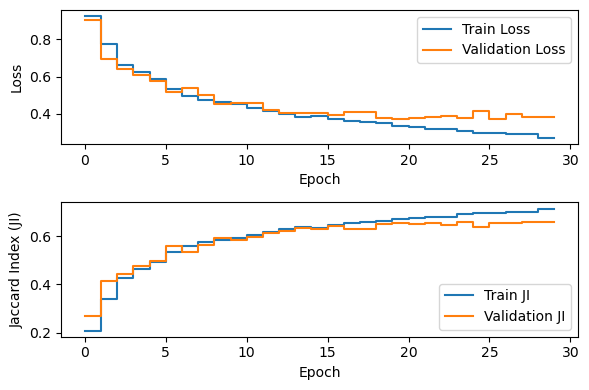

In [149]:
metrics = (pd.read_csv(os.path.join(early_stop_logger.log_dir, "metrics.csv"))
           .ffill())
plot_training_metrics(metrics)

## Evaluating the Trained U-Net

Estimate the segmentations with the U-Net ...

In [150]:
# test_dataset = dt.pytorch.Dataset(pip, test_srcs)
# test_loader = dl.DataLoader(test_dataset, batch_size=2, shuffle=False)
trainer = early_stop_trainer
trainer.test(early_stop_unet_reg, test_loader)
pred_seg = torch.cat(trainer.predict(early_stop_unet_reg, test_loader), dim=0)

Testing: |          | 0/? [00:00<?, ?it/s]

C:\Users\jojac\AppData\Local\Temp\ipykernel_17136\3077789329.py:44: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(image, dtype=torch.float)
C:\Users\jojac\AppData\Local\Temp\ipykernel_17136\3077789329.py:35: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(image, dtype=torch.float)


Testing DataLoader 0: 100%|██████████| 23/23 [00:35<00:00,  0.65it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│    testArgmaxJI_epoch     │    0.6679254770278931     │
│      test_loss_epoch      │     0.372198823568229     │
└───────────────────────────┴───────────────────────────┘

Predicting DataLoader 0: 100%|██████████| 23/23 [00:31<00:00,  0.73it/s]


... plot the U-Net result against the ground truth segmentation ...

C:\Users\jojac\AppData\Local\Temp\ipykernel_17136\3077789329.py:44: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(image, dtype=torch.float)
C:\Users\jojac\AppData\Local\Temp\ipykernel_17136\3077789329.py:35: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(image, dtype=torch.float)


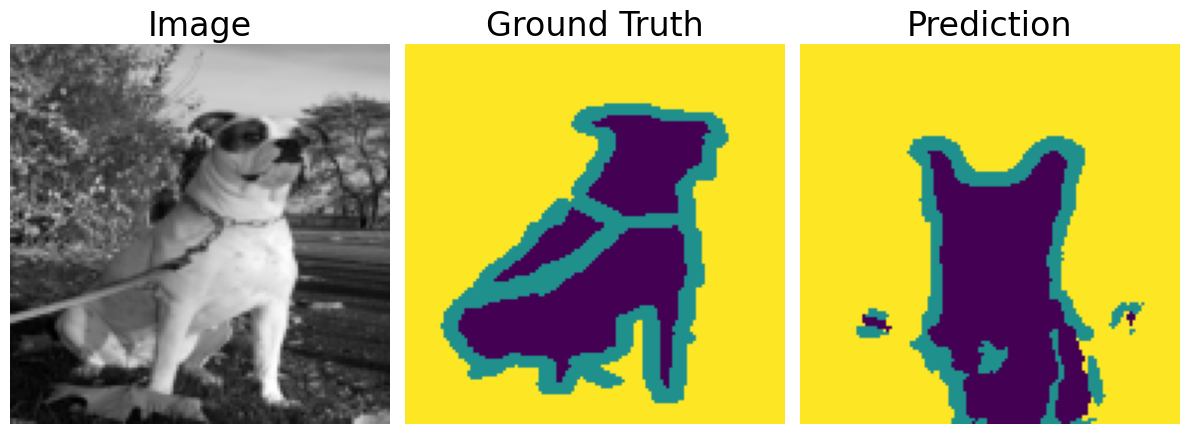

In [154]:
test_image, test_seg = test_dataset[100]

fig, axs = plt.subplots(1, 3, figsize=(12, 9))

axs[0].imshow(test_image[0], cmap="gray")
axs[0].set_title("Image", fontsize=24)
axs[0].set_axis_off()

axs[1].imshow(test_seg.argmax(dim=0))
axs[1].set_title("Ground Truth", fontsize=24)
axs[1].set_axis_off()

axs[2].imshow(pred_seg[0].argmax(dim=0))
axs[2].set_title("Prediction", fontsize=24)
axs[2].set_axis_off()

plt.tight_layout()
plt.show()

... and calcualte the test Jaccard Index.

In [148]:
ji_metric.reset()
ji_seg = ji_metric(pred_seg[0].unsqueeze(0), test_seg.unsqueeze(0))

print(ji_seg)

tensor(0.3055)
